# Configuración básica y carga de datos

In [2]:
import sys
from pathlib import Path
from IPython.display import display
import ipywidgets as widgets
import seaborn as sns
import pandas as pd

# Rutas
PROJECT_ROOT = Path("..").resolve()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "data" / "Results"
SELECTED_DIR = DATA_PROCESSED / "selected"
EDGE_FILES = [
    DATA_PROCESSED / "edgeData_scen1.csv",
    DATA_PROCESSED / "edgeData_scen2.csv",
]

NET_FILE = DATA_RAW / "simulation" / "algeciras.net.xml"
NET_XML = DATA_RAW / "simulation" / "algeciras.net.xml"


sys.path.append(str(PROJECT_ROOT))

from src.milp_solve import load_milp_inputs, solve_sensor_placement
from src.evaluation import compute_flow_coverage
from scripts import make_sensor_pois
from src.evaluation import compare_milp_vs_ga
from IPython.display import display, Image

# Cargar milp_inputs (si no lo tienes ya cargado)
milp_inputs = load_milp_inputs()



# Cargamos milp_inputs ya preprocesado
milp_inputs = load_milp_inputs()

print("Claves disponibles en milp_inputs:", milp_inputs.keys())
print("Ejemplo flows:")
display(milp_inputs["flows"].head())
print("Ejemplo edges:")
display(milp_inputs["edges"].head())

Claves disponibles en milp_inputs: dict_keys(['flows', 'edges', 'nodes', 'entry_nodes', 'exit_nodes', 'O', 'D', 'M'])
Ejemplo flows:


,scenario,edge_id,tau,begin,end,flow_veh_s,flow_veh_h
0,scen1,-1097680628#0,0,0.0,60.0,0.000000,0.0
1,scen1,-1108932288#2,0,0.0,60.0,0.016667,60.0
2,scen1,-1108932289#0,0,0.0,60.0,0.033333,120.0
3,scen1,-1108932289#1,0,0.0,60.0,0.016667,60.0
4,scen1,-1312203992,0,0.0,60.0,0.000000,0.0


Ejemplo edges:


,edge_id,from_node,to_node
0,-1097680628#0,6380710388,288435676
1,-1108932288#0,12145934094,6295741084
2,-1108932288#1,12145934075,12145934094
3,-1108932288#2,10146578305,12145934075
4,-1108932289#0,5244158193,10146578306


# Re-ejecutar preprocesamiento completo

In [4]:
from src import preprocessing


print("Usando edgeData:")
for p in EDGE_FILES:
    print("  -", p)

print("Usando red:", NET_FILE)

milp_inputs = preprocessing.construir_milp_inputs(

)

print("\nPreprocesamiento completado. milp_inputs.pkl actualizado.")
print("Claves:", milp_inputs.keys())

Usando edgeData:
  - C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\edgeData_scen1.csv
  - C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\edgeData_scen2.csv
Usando red: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\raw\simulation\algeciras.net.xml
Cargando edgeData desde: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\edgeData_scen1.csv
Cargando edgeData desde: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\edgeData_scen2.csv
No se encontró 'nVehContrib'. Usando 'entered' para el flujo.
Leyendo red desde: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\raw\simulation\algeciras.net.xml
Total de nodos: 1421
Nodos solo-entrada (candidatos O): 15
Nodos solo-salida (candidatos D): 18
O calculado para 190 combinaciones (scenario, node, tau).
D calculado para 122 combinaciones (scenario, node, tau).
Máximo flujo observado (veh/h): 1680.00
Big-M calculado con factor 1.5: 2520.00

Preprocesamiento completado

# Ejecutar el MILP con B sensores

In [2]:
from scripts.run_milp import run_milp_experiment

# Ejecutar MILP con B sensores y guardar selección en data/processed/selected
milp_run = run_milp_experiment(
    B=20,
    selection_dir=DATA_PROCESSED / "selected",
)


display(milp_run["df_cov"])

milp_run

=== Ejecutando MILP de colocación de sensores (formulación tipo paper) ===
Presupuesto de sensores B = 20

Estado del solver: Optimal
Valor óptimo de la función objetivo (suma de residuos + slacks): 0.2600000010664902
Número de arcos con sensor: 20 (B = 20)

Primeros arcos seleccionados:
  - -1442217813#1
  - 1312203990#0
  - 1312207895#0
  - 22689399#3
  - 22690112
  - 22690218#0
  - 22740417#2
  - 22740446#2
  - 30917843#5
  - 542415707#3
  - 542415708#0
  - 640902593#0
  - 669871301#0
  - 672315013
  - 92848448#1.135
  - 92848448#1.291
  - 92848448#2
  - E22
  - E6
  - E8

=== Métricas de cobertura de flujo ===
  scenario  total_flow_veh_h  sensed_flow_veh_h  coverage_ratio  num_sensors
0    scen1         7075860.0           115500.0        0.016323           20
1    scen2         1621260.0            60780.0        0.037489           20
2      ALL         8697120.0           176280.0        0.020269           20
Selection file saved to: C:\Users\ignag\OneDrive\Documentos\TSLP_algec

,scenario,total_flow_veh_h,sensed_flow_veh_h,coverage_ratio,num_sensors
0,scen1,7075860.0,115500.0,0.016323,20
1,scen2,1621260.0,60780.0,0.037489,20
2,ALL,8697120.0,176280.0,0.020269,20


{'result': {'status': 'Optimal',
  'objective_value': 0.2600000010664902,
  'selected_edges': ['-1442217813#1',
   '1312203990#0',
   '1312207895#0',
   '22689399#3',
   '22690112',
   '22690218#0',
   '22740417#2',
   '22740446#2',
   '30917843#5',
   '542415707#3',
   '542415708#0',
   '640902593#0',
   '669871301#0',
   '672315013',
   '92848448#1.135',
   '92848448#1.291',
   '92848448#2',
   'E22',
   'E6',
   'E8'],
  'x_values': {'-1097680628#0': 0.0,
   '-1108932288#0': 0.0,
   '-1108932288#1': 0.0,
   '-1108932288#2': 0.0,
   '-1108932289#0': 0.0,
   '-1108932289#1': 0.0,
   '-1312203992': 0.0,
   '-1312204011#0': 0.0,
   '-1312204011#1': 0.0,
   '-1312204011#2': 0.0,
   '-1312204011#3': 0.0,
   '-1312204011#4': 0.0,
   '-1312204017#0': 0.0,
   '-1312204017#1': 0.0,
   '-1312204030#0': 0.0,
   '-1312204030#1': 0.0,
   '-1312242535': 0.0,
   '-1442217813#0': 0.0,
   '-1442217813#1': 1.0,
   '-241782378#0': 0.0,
   '-241782378#1': 0.0,
   '-27235970#10': 0.0,
   '-27235970#11': 

# Ejecutar Algoritmo Genético (GA)

--- [TrafficNetwork] Inicializando ---
    -> Usando milp_inputs proporcionados externally.
    -> Buscando critical_edges en: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\critical_edges.txt
    -> Critical Edges cargados: 236
    -> Ciclos cargados: 22, Cortes cargados: 1
    -> DEBUG First Cycle: ['22740417#2', '22740417#1', '22740417#0', '22740417#5', '22740417#4', '22740417#3']
    -> DEBUG First 5 Edges: ['-1097680628#0', '-1108932288#0', '-1108932288#1', '-1108932288#2', '-1108932289#0']
    -> Pre-calculando vectores Surrogate...
--- [TrafficNetwork] Inicialización completa ---
=== GA Setup ===
Edges: 699, Budget: 20, k: 1
Pop: 200, Gens: 80, Cross: 0.80, Mut(ind): 0.35, Tourn: 3
[DEBUG] Individuos únicos al inicio: 200/200
Evaluando población inicial (Surrogate)...
gen	nevals	min    	avg    
1  	180   	427.917	431.456
2  	169   	426.667	430.442
3  	163   	426.667	429.646
4  	174   	425.417	428.944
5  	169   	425.417	428.15 
6  	163   	425.417	427.577
7  	163

{'best': [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  

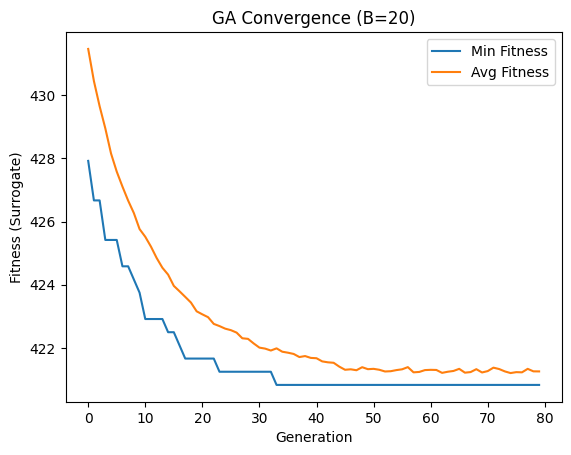

In [3]:
from scripts.run_ga import run_ga_experiment

ga_result = run_ga_experiment(
    milp_inputs=milp_inputs,
    population_size=200,
    max_generations=80,
    sensor_budget=20,
    p_crossover=0.8,
    p_mutation=0.35,      
    tournament_size=3,
    random_seed=42,
    k_coverage=1,
    validation_freq=0,    
)


ga_result

# Generación de additionals en SUMO

In [4]:
import re
from scripts import make_sensor_pois as mpois

NET_XML = DATA_RAW / "simulation" / "algeciras.net.xml"

# Calculamos los shapes una sola vez (más eficiente)
edge_shapes = mpois.cargar_shapes_net(NET_XML)
print(f"Shapes disponibles para {len(edge_shapes)} edges en {NET_XML}")

# Recorremos TODOS los selected_edges_B*.txt (MILP y GA)
for txt_path in sorted(SELECTED_DIR.glob("selected_edges_B*.txt")):
    print(f"\nProcesando {txt_path.name} ...")
    edge_ids = mpois.leer_selected_edges(txt_path)

    stem = txt_path.stem  # p.ej. "selected_edges_B25" o "selected_edges_B99_GA"

    # Buscar el patrón "_B<number>" en el nombre
    m = re.search(r"_B(\d+)", stem)
    if not m:
        print("  (no se pudo extraer B del nombre, se omite)")
        continue

    B = int(m.group(1))

    # Sufijo extra después de "_B<number>" (por ejemplo "_GA" o nada)
    suffix = stem[m.end():]  # desde donde acaba el número hasta el final

    # Construimos el nombre del .add.xml manteniendo el sufijo si existe
    #   selected_edges_B25.txt      → sensors_B25.add.xml
    #   selected_edges_B99_GA.txt   → sensors_B99_GA.add.xml
    if suffix:
        output_add = SELECTED_DIR / f"sensors_B{B}{suffix}.add.xml"
    else:
        output_add = SELECTED_DIR / f"sensors_B{B}.add.xml"

    mpois.escribir_pois(output_add, edge_ids, edge_shapes)

Shapes disponibles para 6912 edges en C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\raw\simulation\algeciras.net.xml

Procesando selected_edges_B10.txt ...
POIs de sensores guardados en: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\selected\sensors_B10.add.xml

Procesando selected_edges_B100_GA.txt ...
POIs de sensores guardados en: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\selected\sensors_B100_GA.add.xml

Procesando selected_edges_B10_GA.txt ...
POIs de sensores guardados en: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\selected\sensors_B10_GA.add.xml

Procesando selected_edges_B13.txt ...
POIs de sensores guardados en: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\selected\sensors_B13.add.xml

Procesando selected_edges_B15.txt ...
POIs de sensores guardados en: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\selected\sensors_B15.add.xml

Procesando selected_edges_B20.txt ...
P

# Dashboard sencillo de imágenes de configuración de sensores

In [14]:
def show_milp_image(B: int):
    """
    Muestra la imagen de resultados del MILP almacenada en:
        data/Results/{B}_MILP.png
    """
    img_path = RESULTS_DIR / f"{B}_MILP.png"
    if not img_path.exists():
        print(f"No se encontró la imagen {img_path}")
        return
    display(Image(filename=str(img_path)))

# Widget: deslizador para elegir B (ajusta el rango a tus valores disponibles)
B_slider = widgets.IntSlider(
    value=20,
    min=10,
    max=40,
    step=5,
    description="Sensors B:",
    continuous_update=False,
)

ui = widgets.VBox([B_slider])

out = widgets.Output()

def on_B_change(change):
    if change["name"] == "value":
        B = change["new"]
        out.clear_output()
        with out:
            print(f"Configuración de sensores para B = {B}")
            show_milp_image(B)

B_slider.observe(on_B_change, names="value")

display(ui, out)

# Llamada inicial
on_B_change({"name": "value", "new": B_slider.value})

Output()

In [6]:
def show_GA_image(B: int):
    """
    Muestra la imagen de resultados del GA almacenada en:
        data/Results/{B}_GA.png
    """
    img_path = RESULTS_DIR / f"{B}_GA.png"
    if not img_path.exists():
        print(f"No se encontró la imagen {img_path}")
        return
    display(Image(filename=str(img_path)))

# Widget: deslizador para elegir B (ajusta el rango a tus valores disponibles)
B_slider = widgets.IntSlider(
    value=20,
    min=20,
    max=90,
    step=10,
    description="Sensors B:",
    continuous_update=False,
)

ui = widgets.VBox([B_slider])

out = widgets.Output()

def on_B_change(change):
    if change["name"] == "value":
        B = change["new"]
        out.clear_output()
        with out:
            print(f"Configuración de sensores para B = {B}")
            show_GA_image(B)

B_slider.observe(on_B_change, names="value")

display(ui, out)

# Llamada inicial
on_B_change({"name": "value", "new": B_slider.value})

Output()

In [3]:
df_comp = compare_milp_vs_ga(
    milp_inputs=milp_inputs,
    selected_dir=SELECTED_DIR,
    results_dir=RESULTS_DIR / "evaluation",
)

display(df_comp)

Budgets B comunes encontrados (MILP & GA): [10, 20, 30, 40, 50]

=== Comparando B = 10 ===
Figura de comparación guardada en: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\Results\evaluation\comparison_MILP_vs_GA_B10.png

=== Comparando B = 20 ===
Figura de comparación guardada en: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\Results\evaluation\comparison_MILP_vs_GA_B20.png

=== Comparando B = 30 ===
Figura de comparación guardada en: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\Results\evaluation\comparison_MILP_vs_GA_B30.png

=== Comparando B = 40 ===
Figura de comparación guardada en: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\Results\evaluation\comparison_MILP_vs_GA_B40.png

=== Comparando B = 50 ===
Figura de comparación guardada en: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\Results\evaluation\comparison_MILP_vs_GA_B50.png


,B,algo,scenario,total_flow_veh_h,sensed_flow_veh_h,coverage_ratio
0,10,MILP,ALL,8697120.0,144060.0,0.016564
1,10,GA,ALL,8697120.0,101100.0,0.011625
2,20,MILP,ALL,8697120.0,708900.0,0.081510
3,20,GA,ALL,8697120.0,237420.0,0.027299
4,30,MILP,ALL,8697120.0,41880.0,0.004815
5,30,GA,ALL,8697120.0,533580.0,0.061351
6,40,MILP,ALL,8697120.0,46140.0,0.005305
7,40,GA,ALL,8697120.0,529920.0,0.060931
8,50,MILP,ALL,8697120.0,1285740.0,0.147835
9,50,GA,ALL,8697120.0,677280.0,0.077874


# Simulated Annealing (SA)

In [7]:
from src.sa_algorithm import SimulatedAnnealing, build_domain_from_preprocessing
from src.ga_algorithm import save_ga_solution  # la función ya sabe leer domain.edge_ids

# 1) Construir dominio a partir del preprocessing
#    (usa los edgeData_scen*.csv y genera un flujo medio por edge)
domain = build_domain_from_preprocessing()

budget = 20

print(f"Running SA with B={budget}...")
sa = SimulatedAnnealing(
    domain=domain,
    budget=budget,
    max_iter=250,
    initial_temp=1000.0,
)

sa_result = sa.run(seed=42)

print("Best SA Fitness (uncovered flow):", sa_result["best_fitness"])
print("Active sensors in best solution:", int(sa_result["best_solution"].sum()))

# 2) Guardar solución en formato compatible con SUMO/NETEDIT
output_sa_path = DATA_PROCESSED / "selected" / f"selected_edges_B{budget}_SA.txt"
save_ga_solution(sa_result["best_solution"], domain, output_sa_path)
print(f"SA Solution saved to {output_sa_path}")


Cargando edgeData desde: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\edgeData_scen1.csv
Cargando edgeData desde: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\edgeData_scen2.csv
No se encontró 'nVehContrib'. Usando 'entered' para el flujo.
[build_domain_from_preprocessing] Dominio construido con 699 edges.
Running SA with B=20...
Best SA Fitness (uncovered flow): 137959.0986143782
Active sensors in best solution: 20
[GA] Solución guardada en: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\selected\selected_edges_B20_SA.txt
SA Solution saved to C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\selected\selected_edges_B20_SA.txt


# Multi-Seed Experiments & Variance Analysis

--- [TrafficNetwork] Inicializando ---
    -> Cargando milp_inputs por defecto desde disco.
Cargando edgeData desde: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\edgeData_scen1.csv
Cargando edgeData desde: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\edgeData_scen2.csv
No se encontró 'nVehContrib'. Usando 'entered' para el flujo.
Leyendo red desde: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\raw\simulation\algeciras.net.xml
Total de nodos: 1421
Nodos solo-entrada (candidatos O): 15
Nodos solo-salida (candidatos D): 18
O calculado para 190 combinaciones (scenario, node, tau).
D calculado para 122 combinaciones (scenario, node, tau).
Máximo flujo observado (veh/h): 1680.00
Big-M calculado con factor 1.5: 2520.00
    -> Buscando critical_edges en: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\critical_edges.txt
    -> Critical Edges cargados: 238
    -> Ciclos cargados: 23, Cortes cargados: 1
    -> DEBUG First Cycle: [

Running GA B=20: 100%|██████████| 5/5 [00:03<00:00,  1.51it/s]


Running Multi-seed SA...


Running SA B=20: 100%|██████████| 5/5 [00:00<00:00, 12.35it/s]


,count,mean,std,min,25%,50%,75%,max
algorithm,,,,,,,,
GA,5.0,149.031969,13.287489,128.9801,145.903955,148.132184,159.722222,162.421384
SA,5.0,432.166667,0.684653,431.2500,431.666667,432.500000,432.500000,432.916667


Plot saved to C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\Results\variance_analysis.png


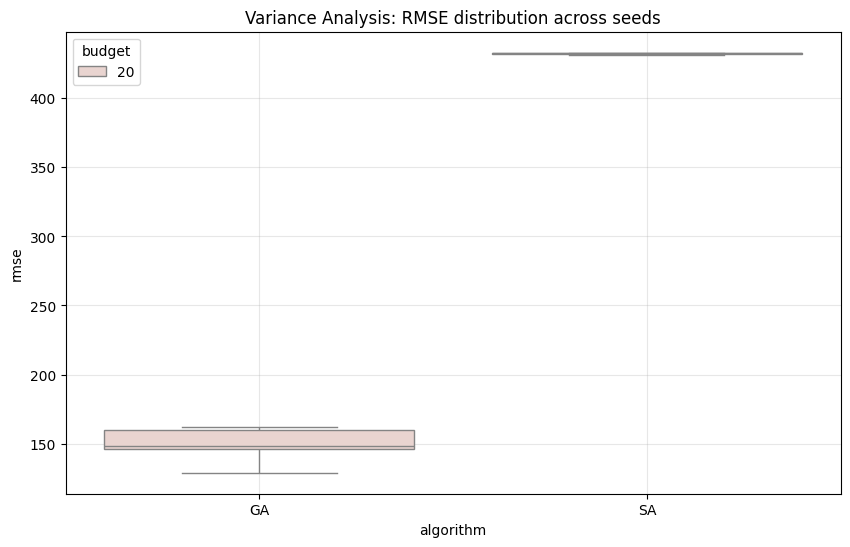

In [ ]:
from src.experiments import run_multi_seed_experiment, plot_variance_analysis
import pandas as pd
from src.ga_algorithm import TrafficNetwork
from src.sa_algorithm import SimulatedAnnealing

network = TrafficNetwork(DATA_PROCESSED / "edgeData_scen1.csv")

# Define seeds
seeds = [42, 10, 2023, 777, 99]
budget = 20

# Run GA
print("Running Multi-seed GA...")
df_ga = run_multi_seed_experiment(
    network,
    "GA",
    budget,
    seeds,
    population_size=50,
    max_generations=20,
)

# Run SA (mismos seeds, misma B, pero con hiperparámetros de SA)
print("Running Multi-seed SA...")
df_sa = run_multi_seed_experiment(
    network,
    "SA",
    budget,
    seeds,
    max_iter= 500,
    initial_temp=5000.0,   
    cooling_rate=0.95,     
    min_temp=1.0,          
)
# Combine results
df_all = pd.concat([df_ga, df_sa], ignore_index=True)

# Display results (misma métrica RMSE para GA y SA)
display(df_all.groupby("algorithm")["rmse"].describe())

# Plot Variance
output_plot = RESULTS_DIR / "variance_analysis.png"
plot_variance_analysis(df_all, output_path=output_plot)

Cargando edgeData desde: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\edgeData_scen1.csv
Cargando edgeData desde: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\edgeData_scen2.csv
No se encontró 'nVehContrib'. Usando 'entered' para el flujo.
Leyendo red desde: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\raw\simulation\algeciras.net.xml
Total de nodos: 1421
Nodos solo-entrada (candidatos O): 15
Nodos solo-salida (candidatos D): 18
O calculado para 190 combinaciones (scenario, node, tau).
D calculado para 122 combinaciones (scenario, node, tau).
Máximo flujo observado (veh/h): 1680.00
Big-M calculado con factor 1.5: 2520.00

λ = 0.0
--- [TrafficNetwork] Inicializando ---
    -> Usando milp_inputs proporcionados externally.
    -> Buscando critical_edges en: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\critical_edges.txt
    -> Critical Edges cargados: 238
    -> Ciclos cargados: 23, Cortes cargados: 1
    -> DEBUG First

,lambda,min_surrogate_last,avg_surrogate_last,txt_path,png_path
0,0.0,429.166667,430.0,C:\Users\ignag\OneDrive\Documentos\TSLP_algeci...,C:\Users\ignag\OneDrive\Documentos\TSLP_algeci...
1,0.1,429.166667,430.0,C:\Users\ignag\OneDrive\Documentos\TSLP_algeci...,C:\Users\ignag\OneDrive\Documentos\TSLP_algeci...
2,1.0,429.166667,430.0,C:\Users\ignag\OneDrive\Documentos\TSLP_algeci...,C:\Users\ignag\OneDrive\Documentos\TSLP_algeci...
3,10.0,429.166667,430.0,C:\Users\ignag\OneDrive\Documentos\TSLP_algeci...,C:\Users\ignag\OneDrive\Documentos\TSLP_algeci...
4,50.0,429.166667,430.0,C:\Users\ignag\OneDrive\Documentos\TSLP_algeci...,C:\Users\ignag\OneDrive\Documentos\TSLP_algeci...
5,100.0,429.166667,430.0,C:\Users\ignag\OneDrive\Documentos\TSLP_algeci...,C:\Users\ignag\OneDrive\Documentos\TSLP_algeci...
6,200.0,429.166667,430.0,C:\Users\ignag\OneDrive\Documentos\TSLP_algeci...,C:\Users\ignag\OneDrive\Documentos\TSLP_algeci...
7,500.0,429.166667,430.0,C:\Users\ignag\OneDrive\Documentos\TSLP_algeci...,C:\Users\ignag\OneDrive\Documentos\TSLP_algeci...


Summary saved to: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\Results\evaluation\lambda_sweep\lambda_sweep_summary.csv


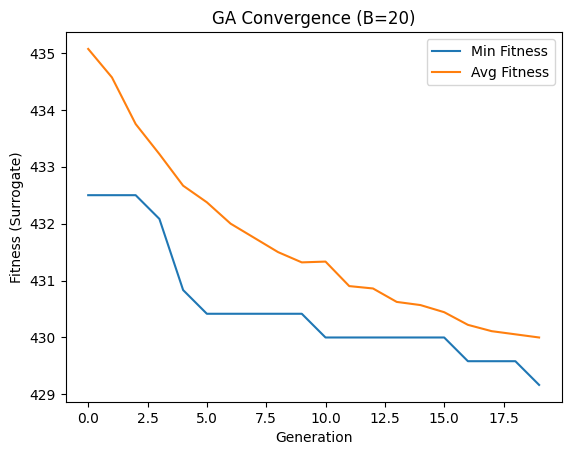

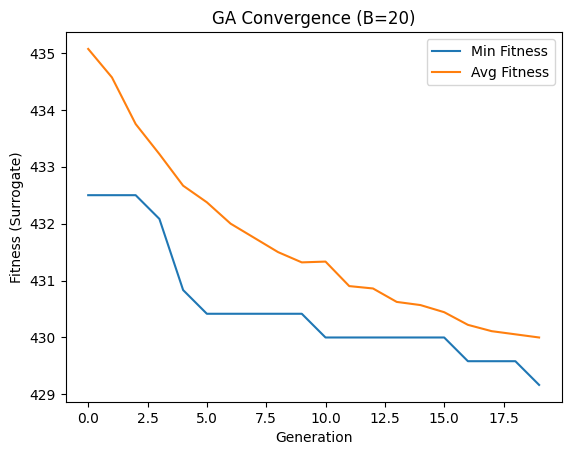

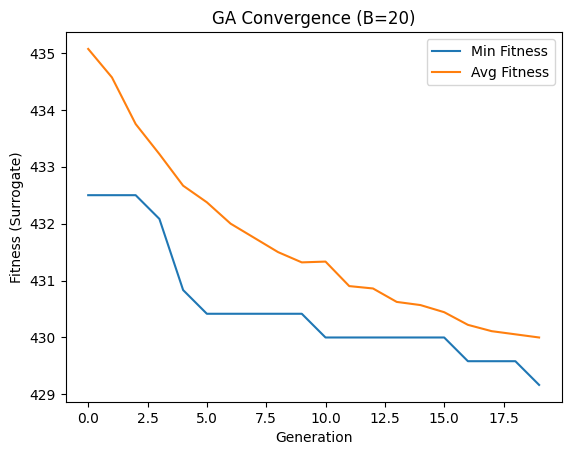

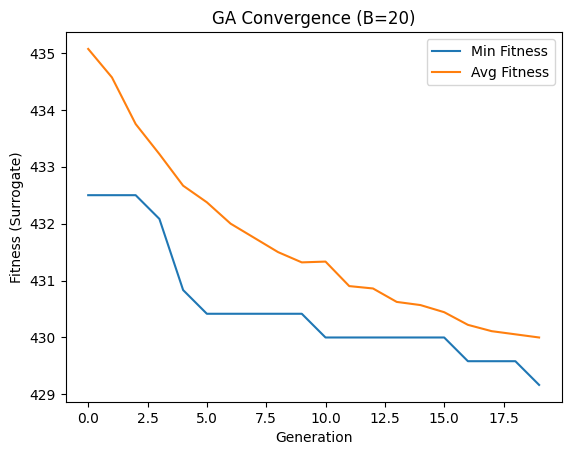

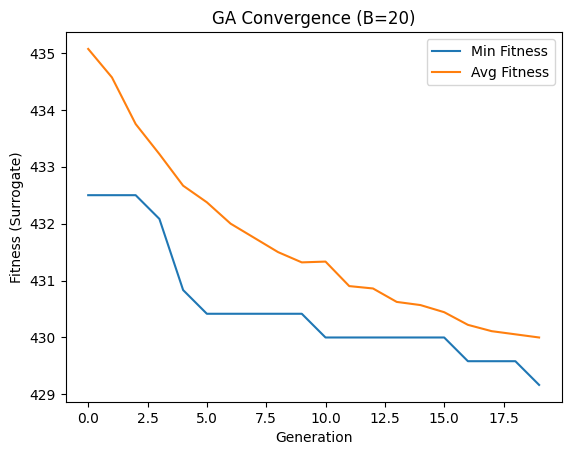

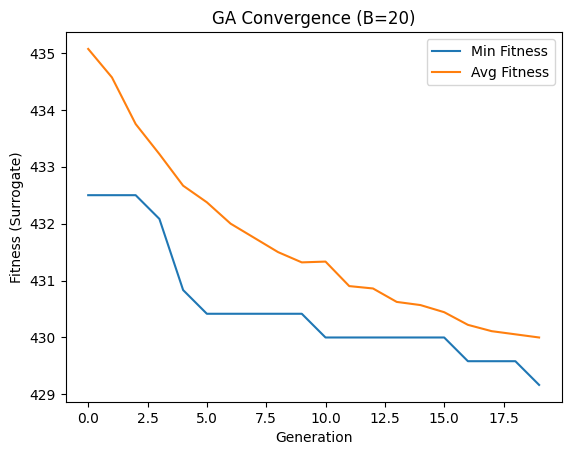

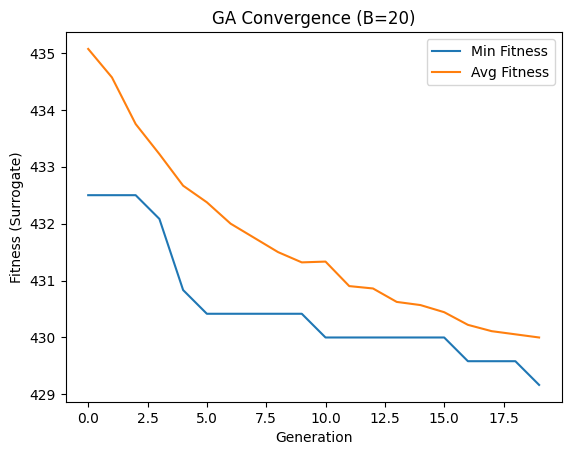

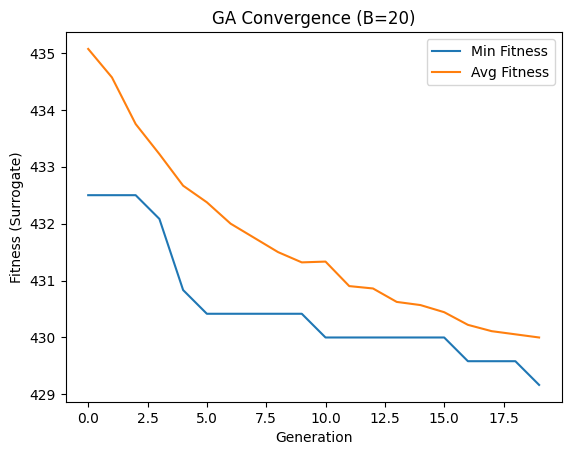

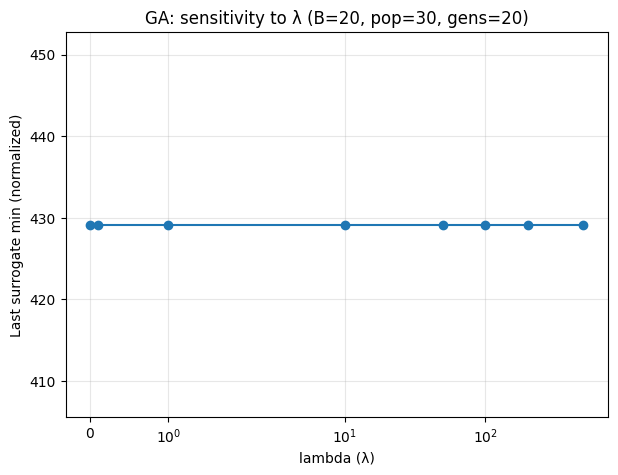

Figure saved to: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\Results\evaluation\lambda_sweep\lambda_vs_last_min_surrogate.png


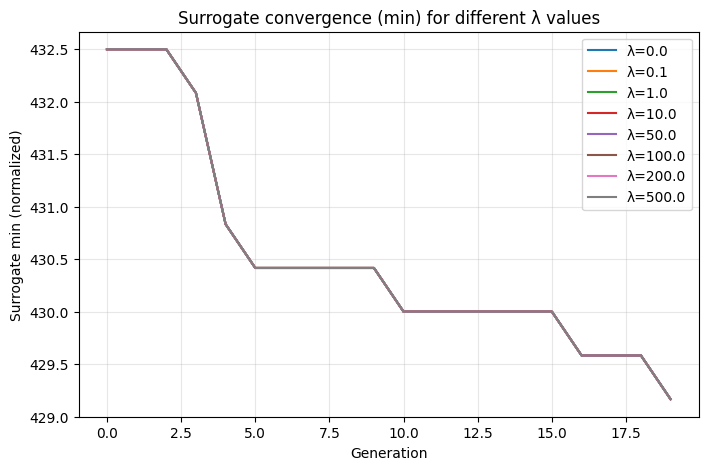

Figure saved to: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\Results\evaluation\lambda_sweep\lambda_sweep_convergence_surrogate_min.png


In [5]:

# --- Sweep de lambda (λ) para justificarlo en el paper ---
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.preprocessing import construir_milp_inputs
from scripts.run_ga import run_ga_experiment

# Rutas
EVAL_DIR = PROJECT_ROOT / "data" / "Results" / "evaluation" / "lambda_sweep"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

# 1) Cargamos milp_inputs UNA sola vez
milp_inputs = construir_milp_inputs()

# 2) Barrido de lambdas
lambda_values = [0.0, 0.1, 1.0, 10.0, 50.0, 100.0, 200.0, 500.0]

# 3) Parámetros "ligeros"
B = 20
POP = 30
GENS = 20
VAL_FREQ = 0   # 0 = surrogate only (rápido). Pon 5 si quieres validar exact (caro)
SEED = 42

rows = []
all_hist = {}

for lam in lambda_values:
    print("\n" + "="*80)
    print(f"λ = {lam}")

    ga = run_ga_experiment(
        milp_inputs=milp_inputs,
        population_size=POP,
        max_generations=GENS,
        sensor_budget=B,
        random_seed=SEED,
        validation_freq=VAL_FREQ,
        # >>> ESTE ES EL CAMBIO CLAVE <<<
        lambda_flow_balance=lam,
    )

    # En tu run_ga.py actual se devuelve logbook (no min_hist/avg_hist)
    logbook = ga.get("logbook", None)
    if logbook is not None:
        min_hist = list(logbook.select("min"))
        avg_hist = list(logbook.select("avg"))
    else:
        min_hist, avg_hist = [], []

    all_hist[lam] = {"min": min_hist, "avg": avg_hist}

    rows.append({
        "lambda": lam,
        "min_surrogate_last": float(min_hist[-1]) if len(min_hist) else np.nan,
        "avg_surrogate_last": float(avg_hist[-1]) if len(avg_hist) else np.nan,
        "txt_path": str(ga.get("txt_path", "")),
        "png_path": str(ga.get("png_path", "")),
    })

# Summary table
df_lam = pd.DataFrame(rows).sort_values("lambda")
display(df_lam)

csv_out = EVAL_DIR / "lambda_sweep_summary.csv"
df_lam.to_csv(csv_out, index=False)
print(f"Summary saved to: {csv_out}")

# Plot 1: last surrogate min vs lambda
plt.figure(figsize=(7, 5))
plt.plot(df_lam["lambda"], df_lam["min_surrogate_last"], marker="o")
plt.xscale("symlog")  # allows lambda=0
plt.xlabel("lambda (λ)")
plt.ylabel("Last surrogate min (normalized)")
plt.title(f"GA: sensitivity to λ (B={B}, pop={POP}, gens={GENS})")
plt.grid(True, alpha=0.3)
fig1 = EVAL_DIR / "lambda_vs_last_min_surrogate.png"
plt.savefig(fig1, dpi=200, bbox_inches="tight")
plt.show()
print(f"Figure saved to: {fig1}")

# Plot 2: surrogate min curves per lambda
plt.figure(figsize=(8, 5))
for lam in lambda_values:
    h = all_hist[lam]["min"]
    if len(h):
        plt.plot(h, label=f"λ={lam}")
plt.xlabel("Generation")
plt.ylabel("Surrogate min (normalized)")
plt.title("Surrogate convergence (min) for different λ values")
plt.grid(True, alpha=0.3)
plt.legend()
fig2 = EVAL_DIR / "lambda_sweep_convergence_surrogate_min.png"
plt.savefig(fig2, dpi=200, bbox_inches="tight")
plt.show()
print(f"Figure saved to: {fig2}")


In [6]:
ind = ga["best"]  # o cualquier individuo
key = domain.snapshot_keys[0]
b_bal, f_prior, w_vec = domain.surrogate_data[key]
f_tilde = f_prior.copy()

# ejecuta UNA vez tu bucle de balancing tal cual lo tengas (o llama a tu función)
# ... (tu balancing) ...

imb = domain.A_balance @ f_tilde - b_bal
print("L1 imbalance:", np.sum(np.abs(imb)))


NameError: name 'domain' is not defined